# Phases 12-15: ML Training Pipeline

This notebook implements:
- **Phase 12**: Feature engineering
- **Phase 13**: Stratified train/validation/test split (60/20/20)
- **Phase 14**: Model training, comparison, and selection
- **Phase 15**: Model artifact + metadata saving

## Weak Supervision Disclaimer

The `priority` labels in this project are produced via **rule-based weak supervision** (keywords, punctuation signals like `!`, and sentiment heuristics), not human-verified ground truth.

This means the supervised model primarily learns these heuristic signals and their interactions. Reported performance reflects consistency with weak labels, not necessarily true user urgency. In production, this should be refined using human feedback, active learning, and periodic relabeling.

In [5]:
from __future__ import annotations

import json
import logging
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from textblob import TextBlob

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False


RANDOM_STATE: int = 42
CHUNK_SIZE: int = 25_000

PROJECT_ROOT = Path.cwd().parent

def resolve_input_path(project_root: Path) -> Path:
    # Prefer validated *_fixed files first, then legacy names.
    candidates = [
        project_root / "data" / "labeled" / "labeled_questions_fixed.csv",
        project_root / "data" / "labeled" / "labeled_questions.csv",
        project_root / "data" / "cleaned" / "questions_labeled.csv",
        project_root / "data" / "cleaned" / "questions_for_ml_fixed.csv",
        Path.cwd() / "data" / "labeled" / "labeled_questions_fixed.csv",
        Path.cwd() / "data" / "labeled" / "labeled_questions.csv",
        Path.cwd() / "data" / "cleaned" / "questions_labeled.csv",
        Path.cwd() / "data" / "cleaned" / "questions_for_ml_fixed.csv",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    candidate_text = "\n".join(str(p) for p in candidates)
    raise FileNotFoundError(
        "Missing labeled dataset. Checked:\n"
        f"{candidate_text}\n\n"
        "Run the labeling notebook first (Phase 10 / fix notebook) to generate labeled CSV files."
    )

INPUT_PATH = resolve_input_path(PROJECT_ROOT)
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
MODELS_DIR = PROJECT_ROOT / "models"
LOGS_DIR = PROJECT_ROOT / "logs"

for directory in (SPLITS_DIR, MODELS_DIR, LOGS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    force=True,
)
logger = logging.getLogger("ml_training_pipeline")

logger.info("Resolved input path: %s", INPUT_PATH)


2026-04-23 13:17:09,705 | INFO | Resolved input path: c:\projects\decision-assistant\data\labeled\labeled_questions_fixed.csv


2026-04-23 13:17:13,748 | INFO | Loading labeled dataset...
2026-04-23 13:17:18,275 | INFO | Input shape: (1537843, 6)
2026-04-23 13:18:33,262 | INFO | Sentiment progress: 25000/1537843 rows
2026-04-23 13:18:36,131 | INFO | Sentiment progress: 50000/1537843 rows
2026-04-23 13:18:39,141 | INFO | Sentiment progress: 75000/1537843 rows
2026-04-23 13:18:42,174 | INFO | Sentiment progress: 100000/1537843 rows
2026-04-23 13:18:44,891 | INFO | Sentiment progress: 125000/1537843 rows
2026-04-23 13:18:47,713 | INFO | Sentiment progress: 150000/1537843 rows
2026-04-23 13:18:50,494 | INFO | Sentiment progress: 175000/1537843 rows
2026-04-23 13:18:53,219 | INFO | Sentiment progress: 200000/1537843 rows
2026-04-23 13:18:55,951 | INFO | Sentiment progress: 225000/1537843 rows
2026-04-23 13:18:58,909 | INFO | Sentiment progress: 250000/1537843 rows
2026-04-23 13:19:02,084 | INFO | Sentiment progress: 275000/1537843 rows
2026-04-23 13:19:05,245 | INFO | Sentiment progress: 300000/1537843 rows
2026-04-

,mean,std,skewness
avg_word_length,5.419829,1.300058,54.071758
caps_ratio,0.013074,0.113592,8.573223
char_count,92.227908,56.363372,0.763330
exclamation_count,0.272931,0.917461,34.381811
has_exclamation,0.159827,0.366446,1.856609
has_question,0.256231,0.436551,1.116797
has_urgent_keyword,0.207805,0.405736,1.440323
keyword_count,0.251362,0.540747,2.657815
question_count,0.340604,0.842662,57.752209
sentiment_score,0.021211,0.284997,-0.107212


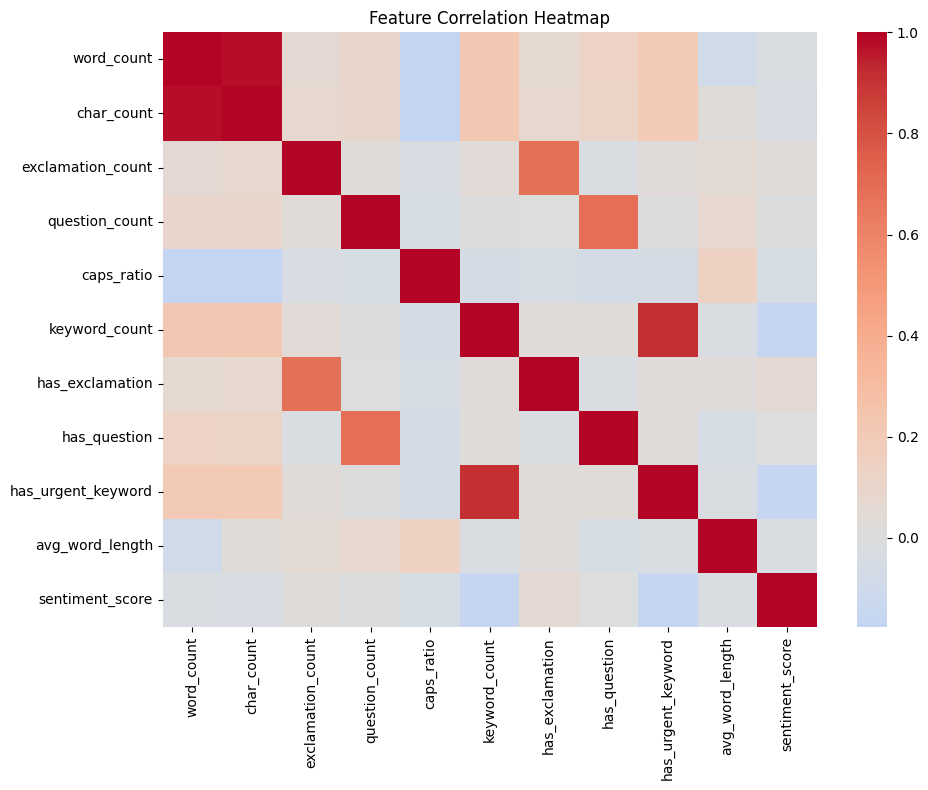

In [6]:
URGENT_KEYWORDS: list[str] = [
    "refund", "broken", "cancel", "down", "help", "urgent", "asap", "fix", "issue", "problem",
    "stuck", "error", "not working", "wrong", "charged", "money", "scam", "fraud",
    "disappointed", "angry", "furious", "terrible", "worst", "useless", "hopeless",
]

def sentiment_in_chunks(text_series: pd.Series, chunk_size: int = CHUNK_SIZE) -> pd.Series:
    values: list[float] = []
    total_rows = len(text_series)
    for start in range(0, total_rows, chunk_size):
        end = min(start + chunk_size, total_rows)
        chunk = text_series.iloc[start:end]
        sentiments = chunk.apply(lambda t: TextBlob(t).sentiment.polarity)
        values.extend(sentiments.tolist())
        logger.info("Sentiment progress: %s/%s rows", end, total_rows)
    return pd.Series(values, index=text_series.index, dtype=float)


def build_features(df: pd.DataFrame, text_col: str = "question_text_for_ml") -> pd.DataFrame:
    text = df[text_col].fillna("").astype(str)

    word_count = text.str.split().str.len().astype(int)
    char_count = text.str.len().astype(int)
    exclamation_count = text.str.count("!").astype(int)
    question_count = text.str.count(r"\?").astype(int)

    letters_only = text.str.replace(r"[^A-Za-z]", "", regex=True)
    uppercase_count = letters_only.str.count(r"[A-Z]").astype(float)
    letter_count = letters_only.str.len().replace(0, np.nan)
    caps_ratio = (uppercase_count / letter_count).fillna(0.0)

    lowered = text.str.lower()
    keyword_count = pd.Series(0, index=text.index, dtype=int)
    for kw in URGENT_KEYWORDS:
        keyword_count += lowered.str.count(rf"\b{kw}\b")

    feature_df = pd.DataFrame(
        {
            "word_count": word_count,
            "char_count": char_count,
            "exclamation_count": exclamation_count,
            "question_count": question_count,
            "caps_ratio": caps_ratio,
            "keyword_count": keyword_count,
            "has_exclamation": (exclamation_count > 0).astype(int),
            "has_question": (question_count > 0).astype(int),
            "has_urgent_keyword": (keyword_count > 0).astype(int),
            "avg_word_length": (char_count / np.maximum(1, word_count)).astype(float),
        }
    )

    feature_df["sentiment_score"] = sentiment_in_chunks(text)
    return feature_df


def normalize_priority_labels(priority_series: pd.Series) -> pd.Series:
    label_map = {
        "urgent": 1,
        "normal": 0,
        "high": 1,
        "low": 0,
        "1": 1,
        "0": 0,
    }
    raw = priority_series.astype(str).str.strip().str.lower()
    mapped = raw.map(label_map)

    if mapped.isna().any():
        unknown = sorted(raw[mapped.isna()].unique().tolist())
        raise ValueError(
            "Unsupported priority label values found: "
            f"{unknown}. Expected values like urgent/normal or 1/0."
        )

    return mapped.astype(int)


logger.info("Loading labeled dataset...")
raw_df = pd.read_csv(INPUT_PATH, low_memory=False)
required_columns = {
    "question_id", "question_text_for_ml", "conversation_id", "author_id", "created_at", "priority"
}
missing = required_columns - set(raw_df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

logger.info("Input shape: %s", raw_df.shape)
X_all = build_features(raw_df, text_col="question_text_for_ml")
y_all = normalize_priority_labels(raw_df["priority"])
logger.info("Priority distribution: %s", y_all.value_counts(normalize=True).to_dict())

feature_stats = X_all.describe().T[["mean", "std"]]
feature_stats["skewness"] = X_all.skew(numeric_only=True)
display(feature_stats.sort_index())

plt.figure(figsize=(10, 8))
sns.heatmap(X_all.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(LOGS_DIR / "feature_correlation_heatmap.png", dpi=150)
plt.show()


In [7]:
logger.info("Creating stratified train/val/test splits...")

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all,
    y_all,
    test_size=0.4,
    stratify=y_all,
    random_state=RANDOM_STATE,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

X_train.to_csv(SPLITS_DIR / "X_train.csv", index=False)
X_val.to_csv(SPLITS_DIR / "X_val.csv", index=False)
X_test.to_csv(SPLITS_DIR / "X_test.csv", index=False)
y_train.to_frame("priority").to_csv(SPLITS_DIR / "y_train.csv", index=False)
y_val.to_frame("priority").to_csv(SPLITS_DIR / "y_val.csv", index=False)
y_test.to_frame("priority").to_csv(SPLITS_DIR / "y_test.csv", index=False)

split_summary = pd.DataFrame(
    {
        "rows": [len(y_train), len(y_val), len(y_test)],
        "urgent_ratio": [y_train.mean(), y_val.mean(), y_test.mean()],
    },
    index=["train", "validation", "test"],
)
display(split_summary)
logger.info("Split files saved under %s", SPLITS_DIR)


2026-04-23 13:21:41,467 | INFO | Creating stratified train/val/test splits...


,rows,urgent_ratio
train,922705,0.292821
validation,307569,0.292822
test,307569,0.292819


2026-04-23 13:21:45,928 | INFO | Split files saved under c:\projects\decision-assistant\data\splits


2026-04-23 13:21:50,076 | INFO | Training model: dummy
2026-04-23 13:21:55,629 | INFO | Training model: logistic_regression
2026-04-23 13:22:06,039 | INFO | Training model: random_forest
2026-04-23 13:24:45,318 | INFO | Training model: gradient_boosting
2026-04-23 13:34:53,642 | INFO | Training model: xgboost


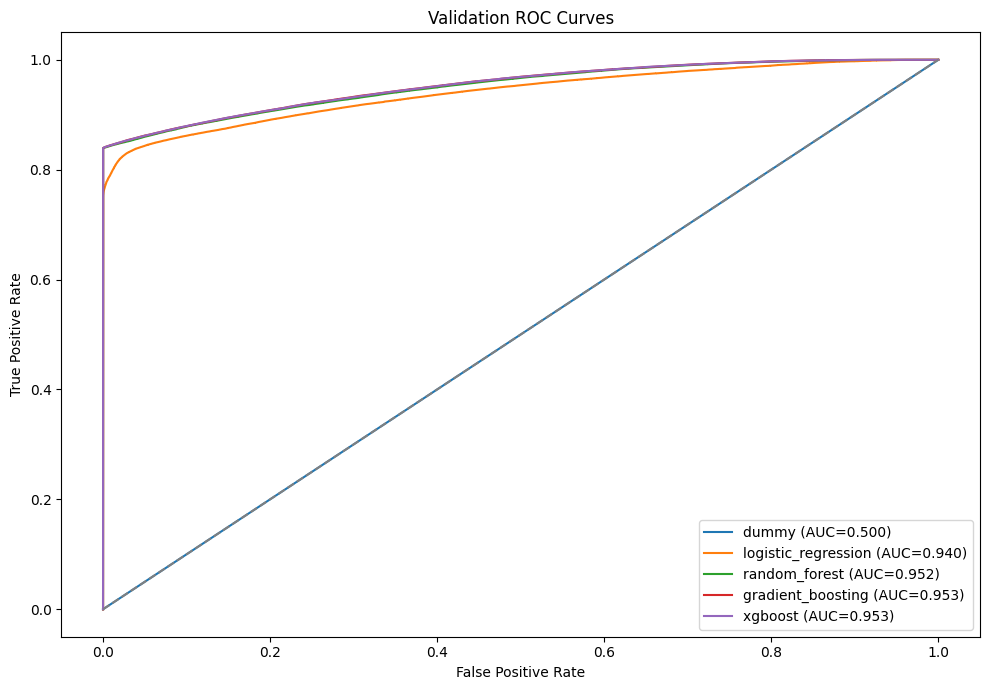

,model,cv_f1_mean,train_val_f1_gap,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,random_forest,0.912111,-0.000428,0.952687,1.000000,0.838423,0.912111,0.951821,0.952898,1.000000,0.839146,0.912539,0.952141
1,gradient_boosting,0.912060,-0.000307,0.952739,1.000000,0.838601,0.912216,0.953785,0.952889,0.999947,0.839157,0.912523,0.953471
2,xgboost,0.912135,-0.000336,0.952718,0.999894,0.838619,0.912183,0.953810,0.952879,0.999749,0.839290,0.912519,0.953450
3,logistic_regression,0.875979,0.000241,0.931544,0.932825,0.825676,0.875986,0.938818,0.931329,0.931330,0.826422,0.875745,0.939975
4,dummy,0.000000,0.000000,0.707179,0.000000,0.000000,0.000000,0.500000,0.707178,0.000000,0.000000,0.000000,0.500000


2026-04-23 13:35:17,096 | INFO | Best model on validation F1: random_forest


In [8]:
SKEWED_FEATURES = [
    "word_count",
    "char_count",
    "exclamation_count",
    "question_count",
    "keyword_count",
]
FEATURE_COLUMNS = X_train.columns.tolist()


def apply_log1p_to_columns(df: pd.DataFrame) -> pd.DataFrame:
    transformed = df.copy()
    for col in SKEWED_FEATURES:
        transformed[col] = np.log1p(transformed[col])
    return transformed


def safe_proba(model: Any, X: pd.DataFrame) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    scores = model.decision_function(X)
    return 1 / (1 + np.exp(-scores))


def evaluate_classifier(model: Any, X: pd.DataFrame, y: pd.Series, split_name: str) -> dict[str, float]:
    preds = model.predict(X)
    proba = safe_proba(model, X)
    return {
        f"{split_name}_accuracy": accuracy_score(y, preds),
        f"{split_name}_precision": precision_score(y, preds, zero_division=0),
        f"{split_name}_recall": recall_score(y, preds, zero_division=0),
        f"{split_name}_f1": f1_score(y, preds, zero_division=0),
        f"{split_name}_roc_auc": roc_auc_score(y, proba),
    }


models: dict[str, Any] = {
    "dummy": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "logistic_regression": Pipeline(
        steps=[
            ("log1p", FunctionTransformer(apply_log1p_to_columns, validate=False)),
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    max_iter=300,
                ),
            ),
        ]
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "gradient_boosting": GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
    ),
}

if HAS_XGBOOST:
    models["xgboost"] = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1,
    )
else:
    logger.warning("xgboost not installed, XGBoost model will be skipped.")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results: list[dict[str, Any]] = []
fitted_models: dict[str, Any] = {}

plt.figure(figsize=(10, 7))

for name, model in models.items():
    logger.info("Training model: %s", name)
    model.fit(X_train, y_train)
    fitted_models[name] = model

    train_metrics = evaluate_classifier(model, X_train, y_train, "train")
    val_metrics = evaluate_classifier(model, X_val, y_val, "val")
    cv_f1 = cross_val_score(model, X_train, y_train, scoring="f1", cv=cv, n_jobs=-1).mean()

    val_proba = safe_proba(model, X_val)
    fpr, tpr, _ = roc_curve(y_val, val_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={val_metrics['val_roc_auc']:.3f})")

    row = {
        "model": name,
        "cv_f1_mean": cv_f1,
        "train_val_f1_gap": train_metrics["train_f1"] - val_metrics["val_f1"],
        **train_metrics,
        **val_metrics,
    }
    results.append(row)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Validation ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(LOGS_DIR / "roc_curves.png", dpi=150)
plt.show()

results_df = pd.DataFrame(results).sort_values(by="val_f1", ascending=False).reset_index(drop=True)
results_df.to_csv(LOGS_DIR / "training_results.csv", index=False)
display(results_df)

best_model_name = results_df.loc[0, "model"]
best_model = fitted_models[best_model_name]
logger.info("Best model on validation F1: %s", best_model_name)


2026-04-23 13:38:52,311 | INFO | Best-model test metrics: {'test_accuracy': 0.9530186722328974, 'test_precision': 1.0, 'test_recall': 0.8395549732406564, 'test_f1': 0.9127805207817763, 'test_roc_auc': 0.9518184484296914}


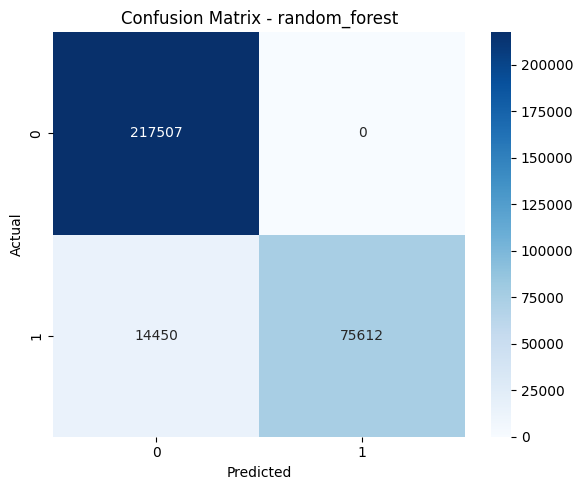

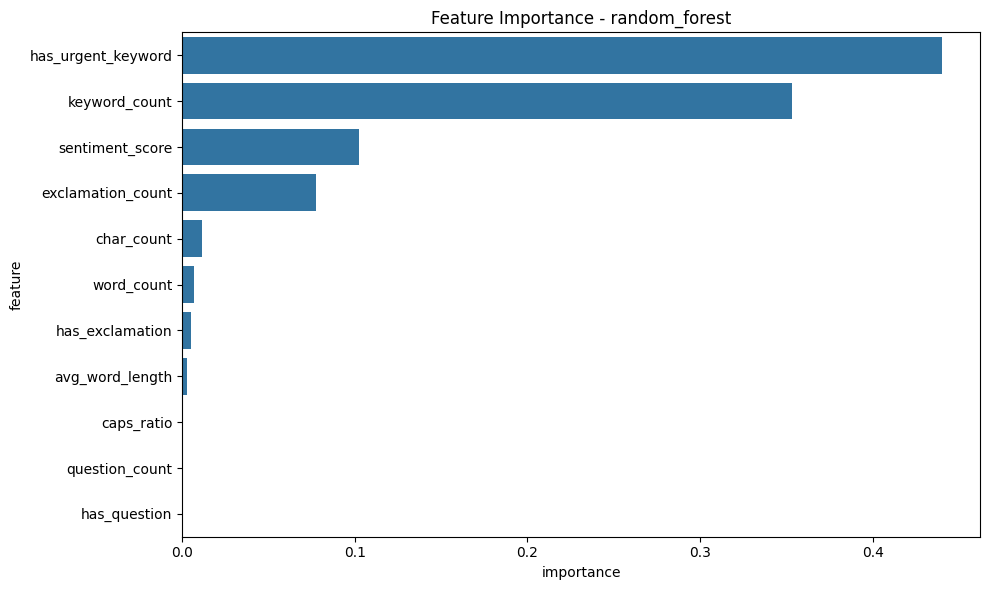

2026-04-23 13:38:53,567 | INFO | Saved model artifact: c:\projects\decision-assistant\models\priority_classifier.pkl
2026-04-23 13:38:53,567 | INFO | Saved metadata: c:\projects\decision-assistant\models\model_metadata.json
2026-04-23 13:38:53,568 | INFO | Saved feature columns: c:\projects\decision-assistant\models\feature_columns.json



Final model selection justification:
Best model: random_forest | Val F1=0.9125, Val ROC-AUC=0.9521, Train-Val F1 gap=-0.0004.
Interpretation: choose the model with strongest validation F1 while monitoring the train-validation gap for overfitting. If the gap is large, reduce model complexity or regularize.


In [9]:
# Test set is touched once: evaluate only the selected best model.
test_metrics = evaluate_classifier(best_model, X_test, y_test, "test")
logger.info("Best-model test metrics: %s", test_metrics)

test_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(LOGS_DIR / "confusion_matrix.png", dpi=150)
plt.show()

# Feature importance for best tree model (insight)
tree_candidates = ["random_forest", "xgboost", "gradient_boosting"]
best_tree_name = next((m for m in results_df["model"].tolist() if m in tree_candidates), None)
if best_tree_name is not None:
    tree_model = fitted_models[best_tree_name]
    importances = getattr(tree_model, "feature_importances_", None)
    if importances is not None:
        fi = pd.DataFrame({"feature": FEATURE_COLUMNS, "importance": importances})
        fi = fi.sort_values("importance", ascending=False).head(20)

        plt.figure(figsize=(10, 6))
        sns.barplot(data=fi, x="importance", y="feature", orient="h")
        plt.title(f"Feature Importance - {best_tree_name}")
        plt.tight_layout()
        plt.savefig(LOGS_DIR / "feature_importance.png", dpi=150)
        plt.show()

model_path = MODELS_DIR / "priority_classifier.pkl"
joblib.dump(best_model, model_path)

feature_cols_path = MODELS_DIR / "feature_columns.json"
feature_cols_path.write_text(json.dumps(FEATURE_COLUMNS, indent=2), encoding="utf-8")

best_row = results_df.iloc[0].to_dict()
metadata = {
    "training_date_utc": datetime.now(timezone.utc).isoformat(),
    "random_state": RANDOM_STATE,
    "input_file": str(INPUT_PATH),
    "feature_columns": FEATURE_COLUMNS,
    "best_model": best_model_name,
    "best_model_validation_metrics": {
        "accuracy": float(best_row["val_accuracy"]),
        "precision": float(best_row["val_precision"]),
        "recall": float(best_row["val_recall"]),
        "f1": float(best_row["val_f1"]),
        "roc_auc": float(best_row["val_roc_auc"]),
        "cv_f1_mean": float(best_row["cv_f1_mean"]),
        "train_val_f1_gap": float(best_row["train_val_f1_gap"]),
    },
    "best_model_test_metrics": {
        "accuracy": float(test_metrics["test_accuracy"]),
        "precision": float(test_metrics["test_precision"]),
        "recall": float(test_metrics["test_recall"]),
        "f1": float(test_metrics["test_f1"]),
        "roc_auc": float(test_metrics["test_roc_auc"]),
    },
    "weak_supervision_note": (
        "Labels are weak supervision outputs (rules for keywords/punctuation/sentiment), "
        "not human ground truth."
    ),
    "model_hyperparameters": best_model.get_params(),
}

metadata_path = MODELS_DIR / "model_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2, default=str), encoding="utf-8")

logger.info("Saved model artifact: %s", model_path)
logger.info("Saved metadata: %s", metadata_path)
logger.info("Saved feature columns: %s", feature_cols_path)

print("\nFinal model selection justification:")
print(
    f"Best model: {best_model_name} | "
    f"Val F1={best_row['val_f1']:.4f}, Val ROC-AUC={best_row['val_roc_auc']:.4f}, "
    f"Train-Val F1 gap={best_row['train_val_f1_gap']:.4f}."
)
print(
    "Interpretation: choose the model with strongest validation F1 while monitoring the train-validation "
    "gap for overfitting. If the gap is large, reduce model complexity or regularize."
)
